<a href="https://colab.research.google.com/github/nandi-projects/5cl_fa26/blob/main/lab3_5cl_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2

# Tier 2 Experiment 3

In [5]:
def linear(m, B):
  return B * m

In [9]:
L = 0.70
wavelength = 635e-9

In [12]:
from numpy._core.multiarray import array
#units are in cm rn
datasets = [
    {
        'label': 'Slit 1',
        'm': np.array([1, 2, 3, 4]),
        'y': np.array([0.2, 0.7, 1, 1.3]),
        'y_err' : 0.1
    },
    {
        'label': 'Slit 2',
        'm': np.array([1, 2, 3, 4]),
        'y': np.array([0.2, 0.6, 1, 1.3]),
        'y_err' : 0.1
    },
    {
        'label': 'Slit 3',
        'm': np.array([1, 2, 3, 4]),
        'y': np.array([0.4, 0.8, 0.9, 1.6]),
        'y_err' : 0.1
    }
]

In [14]:
for data in datasets:
  m_data = data['m']
  y_data = data['y']
  y_err = data['y_err']

#weighted fit
  popt, pcov = curve_fit(linear, m_data, y_data, sigma=y_err, absolute_sigma=True)

#slope
  B_fit = popt[0]
  B_err = np.sqrt(pcov[0,0])

  #calculating slit width from fit
  a_exp = (wavelength * L) / B_fit
  #error propagation
  a_err = a_exp * (B_err / B_fit)

  #chi-squared
  y_model = linear(m_data, B_fit)
  chi2_val = np.sum(((y_data - y_model) / y_err) ** 2)

  dof = len(m_data) - len(popt)
  reduced_chi2 = chi2_val / dof
  p_val = chi2.sf(chi2_val, dof)

  #I used LLM to help write print summary output
  print(f"=== Results for {data['label']} ===")
  print(f"Slope (B): {B_fit:.5e} +/- {B_err:.5e} m")
  print(f"Calculated Slit Width (a): {a_exp:.5e} +/- {a_err:.5e} m")
  print(f"Chi-Squared (χ²): {chi2_val:.3f}")
  print(f"Degrees of Freedom (ν): {dof}")
  print(f"Reduced Chi-Squared (χ²_ν): {reduced_chi2:.3f}")
  print(f"p-value: {p_val:.4f}\n")

=== Results for Slit 1 ===
Slope (B): 3.26667e-01 +/- 1.82574e-02 m
Calculated Slit Width (a): 1.36071e-06 +/- 7.60504e-08 m
Chi-Squared (χ²): 1.867
Degrees of Freedom (ν): 3
Reduced Chi-Squared (χ²_ν): 0.622
p-value: 0.6005

=== Results for Slit 2 ===
Slope (B): 3.20000e-01 +/- 1.82574e-02 m
Calculated Slit Width (a): 1.38906e-06 +/- 7.92522e-08 m
Chi-Squared (χ²): 1.800
Degrees of Freedom (ν): 3
Reduced Chi-Squared (χ²_ν): 0.600
p-value: 0.6149

=== Results for Slit 3 ===
Slope (B): 3.70000e-01 +/- 1.82574e-02 m
Calculated Slit Width (a): 1.20135e-06 +/- 5.92799e-08 m
Chi-Squared (χ²): 6.300
Degrees of Freedom (ν): 3
Reduced Chi-Squared (χ²_ν): 2.100
p-value: 0.0979



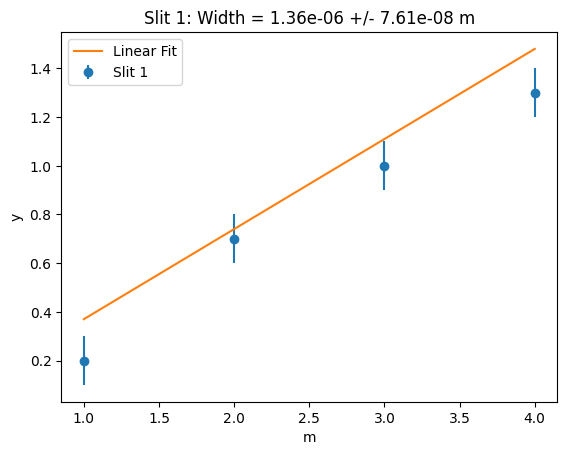

In [19]:
#visualization
plt.errorbar(datasets[0]['m'], datasets[0]['y'], yerr=datasets[0]['y_err'], fmt='o', label='Slit 1')
plt.plot(datasets[0]['m'], linear(datasets[0]['m'], B_fit), label='Linear Fit')
plt.xlabel('m')
plt.ylabel('y')
plt.title('Slit 1: Width = 1.36e-06 +/- 7.61e-08 m')
plt.legend()
plt.show()

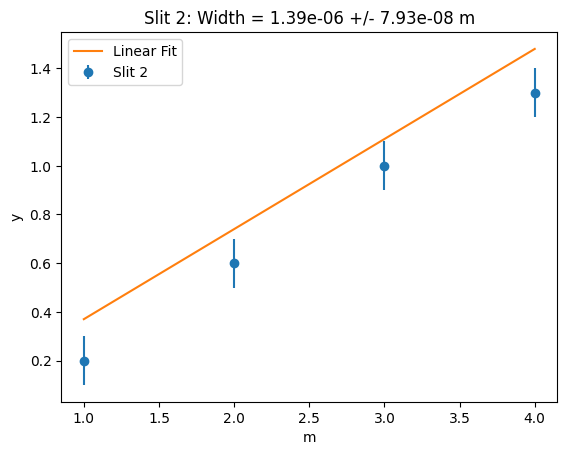

In [18]:
plt.errorbar(datasets[1]['m'], datasets[1]['y'], yerr=datasets[1]['y_err'], fmt='o', label='Slit 2')
plt.plot(datasets[1]['m'], linear(datasets[1]['m'], B_fit), label='Linear Fit')
plt.xlabel('m')
plt.ylabel('y')
plt.title('Slit 2: Width = 1.39e-06 +/- 7.93e-08 m')
plt.legend()
plt.show()

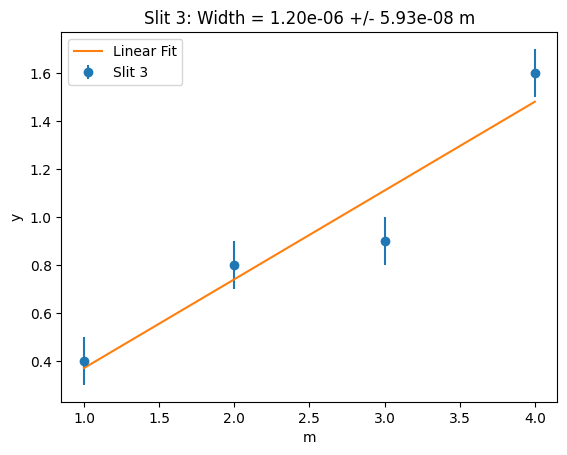

In [20]:
plt.errorbar(datasets[2]['m'], datasets[2]['y'], yerr=datasets[2]['y_err'], fmt='o', label='Slit 3')
plt.plot(datasets[2]['m'], linear(datasets[2]['m'], B_fit), label='Linear Fit')
plt.xlabel('m')
plt.ylabel('y')
plt.title('Slit 3: Width = 1.20e-06 +/- 5.93e-08 m')
plt.legend()
plt.show()

# Tier 2 Experiment 4

In [32]:
m_wire = np.array([1, 2, 3, 4])
data_wires = [
    {'label' : 'Thick wire',
     'm' : np.array([1, 2, 3, 4]),
     'y' : np.array([0.3, 0.2, 0.1, 0.05]),
     'y_err' : 0.2
    },
    {'label' : 'Thin wire',
     'm' : np.array([1, 2, 3, 4]),
     'y' : np.array([0.2, 0.1, 0.07, 0.04]),
     'y_err' : 0.2
     }
]

In [36]:
#tried it with the previous model and it looked really bad, we think it's because the ruler we used was on the screen and has a slight offset, so the fit was messed up
def linear_with_intercept(m, B, y0):
  return B * m + y0

In [37]:
for wire in data_wires:
    popt, pcov = curve_fit(linear_with_intercept, wire['m'], wire['y'], sigma=wire['y_err'], absolute_sigma=True)

    wire['B'] = popt[0]
    wire['y0'] = popt[1]
    wire['B_err'] = np.sqrt(pcov[0, 0])
    wire['a'] = (wavelength * L) / abs(wire['B'])
    wire['a_err'] = wire['a'] * (wire['B_err'] / abs(wire['B']))

    # Chi-squared calculations
    y_fit = linear_with_intercept(wire['m'], wire['B'], wire['y0'])
    chi2_val = np.sum(((wire['y'] - y_fit) / wire['y_err']) ** 2)

    dof = len(wire['m']) - len(popt)
    reduced_chi2 = chi2_val / dof
    p_val = chi2.sf(chi2_val, dof)

    print(f"=== Results for {wire['label']} ===")
    print(f"Slope (B): {wire['B']:.5e} +/- {wire['B_err']:.5e} m")
    print(f"Intercept (y0): {wire['y0']:.5e}")
    print(f"Calculated Wire Width (a): {wire['a']:.5e} +/- {wire['a_err']:.5e} m")
    print(f"Chi-Squared (χ²): {chi2_val:.3f}")
    print(f"Degrees of Freedom (ν): {dof}")
    print(f"Reduced Chi-Squared (χ²_ν): {reduced_chi2:.3f}")
    print(f"p-value: {p_val:.4f}\n")

=== Results for Thick wire ===
Slope (B): -8.50000e-02 +/- 8.94427e-02 m
Intercept (y0): 3.75000e-01
Calculated Wire Width (a): 5.22941e-04 +/- 5.50274e-04 m
Chi-Squared (χ²): 0.019
Degrees of Freedom (ν): 2
Reduced Chi-Squared (χ²_ν): 0.009
p-value: 0.9907

=== Results for Thin wire ===
Slope (B): -5.10000e-02 +/- 8.94427e-02 m
Intercept (y0): 2.30000e-01
Calculated Wire Width (a): 8.71569e-04 +/- 1.52854e-03 m
Chi-Squared (χ²): 0.037
Degrees of Freedom (ν): 2
Reduced Chi-Squared (χ²_ν): 0.018
p-value: 0.9818



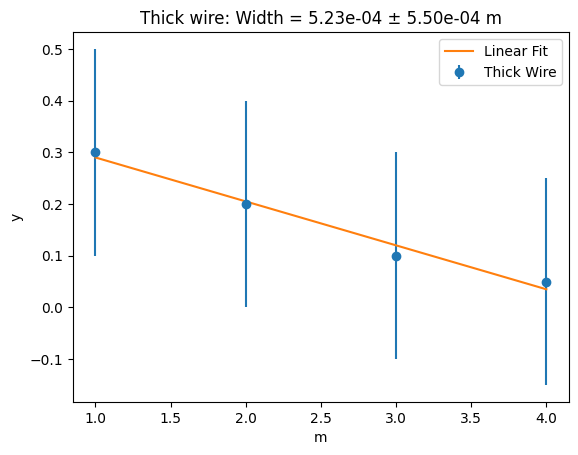

In [38]:
#visualization
#asked LLM for help with prettier formatting

thick = data_wires[0]

plt.errorbar(thick['m'], thick['y'], yerr=thick['y_err'], fmt='o', label='Thick Wire')
plt.plot(thick['m'], linear_with_intercept(thick['m'], thick['B'], thick['y0']), label='Linear Fit')
plt.xlabel('m')
plt.ylabel('y')
plt.title(f"{thick['label']}: Width = {thick['a']:.2e} ± {thick['a_err']:.2e} m")
plt.legend()
plt.show()

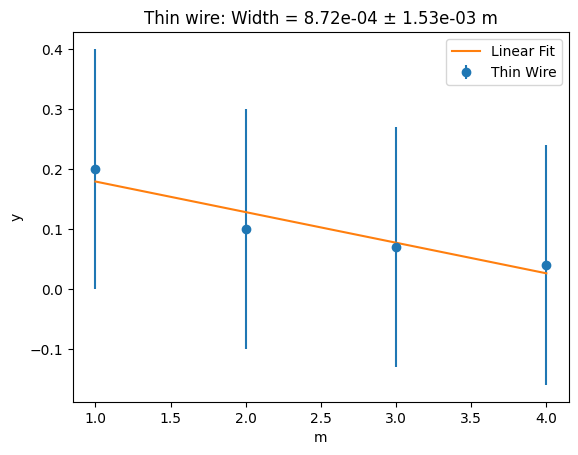

In [40]:
thin = data_wires[1]

plt.errorbar(thin['m'], thin['y'], yerr=thin['y_err'], fmt='o', label='Thin Wire')
plt.plot(thin['m'], linear_with_intercept(thin['m'], thin['B'], thin['y0']), label='Linear Fit')
plt.xlabel('m')
plt.ylabel('y')
plt.title(f"{thin['label']}: Width = {thin['a']:.2e} ± {thin['a_err']:.2e} m")
plt.legend()
plt.show()